In [113]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
import seaborn as sns

# RQ 3: Cluster Analysis & Profiling (Unsupervised Success Profiles)

In [114]:
# Load the dataset
df_spotify = pd.read_csv('../data/spotify_mid.csv')

## Data filter and scaling
Here we create a data subset containing only tracks where *is_hit = 1* (successful songs) 

In [115]:
# Subset for successful songs
hit_df = df_spotify[df_spotify['popularity'] >= 70].copy()

# Define the audio features for clustering
# Excluding key, mode, and time_signature for simplicity, focusing on normalized features
feature_cols = [
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_s'
]

successful_songs = hit_df[feature_cols]
successful_songs

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,230
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,201
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,198
6,0.407,0.1470,-8.822,0.0355,0.8570,0.000003,0.0913,0.0765,141.284,229
7,0.703,0.4440,-9.331,0.0417,0.5590,0.000000,0.0973,0.7120,150.960,242
...,...,...,...,...,...,...,...,...,...,...
112007,0.771,0.8260,-3.978,0.0604,0.1420,0.030000,0.1450,0.1850,100.012,212
112249,0.442,0.7300,-4.673,0.0755,0.0781,0.000005,0.1560,0.3810,97.062,193
112399,0.575,0.3660,-13.644,0.0281,0.5680,0.957000,0.1290,0.4440,100.004,223
112649,0.552,0.6080,-11.211,0.0274,0.1480,0.000021,0.3320,0.8350,88.002,188


In [116]:
# Standardize the features
scaler = StandardScaler()
successful_scaled = scaler.fit_transform(successful_songs)

print(f"Number of 'hit' tracks: {hit_df.shape[0]}")
print(f"Scaled feature matrix shape: {successful_scaled.shape}")

Number of 'hit' tracks: 5472
Scaled feature matrix shape: (5472, 10)


## Optimal K determination (Elbow Method)

Use the elbow method to find the optimal number of clusters by calculating inertia.

### Calculate Inertia for Different K Values
Since the Elbow Point changes on different executions of K-Means, we'll set *n_init* to 10 in order to run K-Means with different initialization of the centroids

In [117]:
# Elbow method to find the optimal number of clusters.
K = range(1, 11)
inertia = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(successful_scaled)
    inertia.append(kmeans.inertia_)

### Visualize Elbow Plot

Plot the elbow graph to identify the optimal number of clusters.

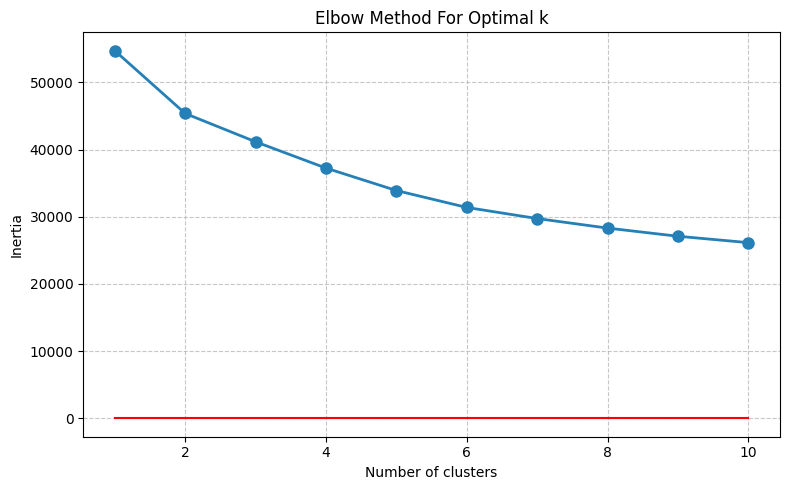

In [118]:
# Plot the elbow graph.
plt.figure(figsize=(8, 5))
plt.plot(K, inertia, "o-", markersize=8, linewidth=2, color="#2580B7")
plt.plot(K, np.zeros(K.stop-1), color="red")

# Add labels to the plot.
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method For Optimal k")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### Find Optimal K with KneeLocator

Use the KneeLocator library to automatically detect the elbow point.

In [119]:
# Use the KneeLocator from the kneed library to find the elbow point.
kl = KneeLocator(K, inertia, curve="convex", direction="decreasing")
elbow_point = kl.elbow
print("Optimal K value: ", elbow_point)

Optimal K value:  5


### Apply K-Means with Optimal K

Apply k-means clustering with the optimal number of clusters and visualize the results.

In [120]:
# Apply the k-means algorithm.
kmeans = KMeans(n_clusters=elbow_point, random_state=42, n_init=10)
hit_df['cluster'] = kmeans.fit_predict(successful_scaled)

For visualization purposes, we apply PCA \
*It's not necessary to center data since we're already scaled it before*

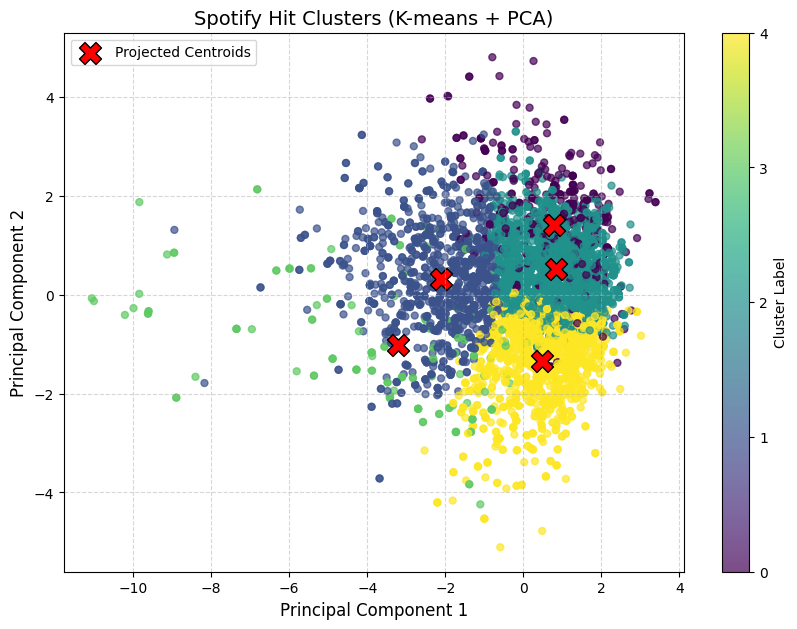

In [121]:
# PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(successful_scaled)

# Project the 10D centroids into the same 2D space
pca_entroids_2d = pca.transform(kmeans.cluster_centers_)

# Visualize the clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_results[:, 0], pca_results[:, 1], 
    c=hit_df['cluster'], 
    cmap='viridis', 
    s=25, alpha=0.7
)

# Plot the projected centroids
plt.scatter(
    pca_entroids_2d[:, 0], pca_entroids_2d[:, 1], 
    s=250, marker="X", c='red', edgecolor='black', label="Projected Centroids"
)

plt.title("Spotify Hit Clusters (K-means + PCA)", fontsize=14)
plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.colorbar(scatter, ticks=range(elbow_point), label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

From this plot, we are able to distiguish some of the 5 clusters but not all of them. 
This is quite expected since we don't have linear correlation between feeatures so PCA doesn't work well.

We'll try to plot applying t-SNE for employing a non-linear approach.

/var/folders/32/cjb5rw_97rjb1kkd58x5p4q80000gn/T/ipykernel_20776/1691899207.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


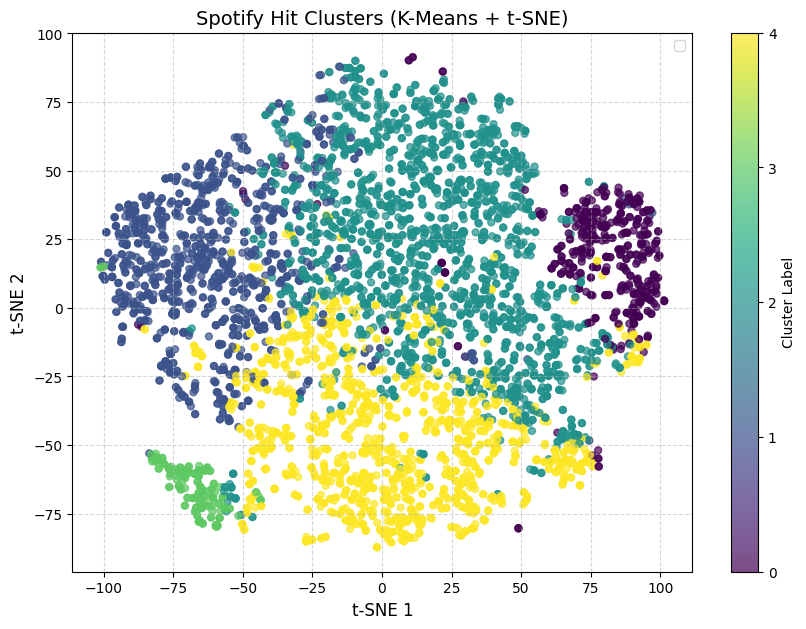

In [122]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(successful_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_results[:, 0], tsne_results[:, 1], 
    c=hit_df['cluster'], 
    cmap='viridis', 
    s=25, alpha=0.7
)

plt.title("Spotify Hit Clusters (K-Means + t-SNE)", fontsize=14)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.colorbar(scatter, ticks=range(elbow_point), label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

We can see that t-SNE shows clear separations between the groups, especially the instrumental and acoustic clusters.

In [123]:
# Profile the clusters (interpret the 10D results)
cluster_profiles = hit_df.groupby('cluster')[feature_cols + ['popularity']].mean().round(3)
cluster_profiles

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,popularity
cluster,,,,,,,,,,,
0,0.719,0.674,-6.253,0.280,0.234,0.008,0.174,0.571,126.307,201.075,76.704
1,0.556,0.425,-9.829,0.047,0.550,0.017,0.144,0.354,112.710,226.687,75.230
2,0.712,0.730,-5.561,0.060,0.144,0.008,0.159,0.642,114.358,201.352,76.358
3,0.494,0.520,-11.798,0.049,0.384,0.751,0.141,0.321,119.938,217.450,74.468
4,0.498,0.784,-5.465,0.062,0.066,0.021,0.215,0.411,132.672,241.773,75.609


In [124]:
# For each cluster, find the 4 genres with the highest count
for i in range(elbow_point):
    top_genres = hit_df[hit_df['cluster'] == i]['track_genre'].value_counts().head(4)
    print(f"Cluster {i} Top Genres: {top_genres.index.tolist()}")

Cluster 0 Top Genres: ['hip-hop', 'latino', 'reggaeton', 'pop']
Cluster 1 Top Genres: ['pop', 'singer-songwriter', 'songwriter', 'indie']
Cluster 2 Top Genres: ['house', 'dance', 'k-pop', 'pop']
Cluster 3 Top Genres: ['indie', 'indie-pop', 'ambient', 'alt-rock']
Cluster 4 Top Genres: ['metal', 'hard-rock', 'alt-rock', 'rock']


### Clusters from K-Means Interpretation
Based on the K-Means clustering results, we have identified five distinct profiles that define successful tracks in this dataset. Each cluster represents a different "formula" for reaching hit status.

---

#### **Cluster 0**
* **Signature Features:** Highest **Speechiness** (0.280) and Very High **Danceability** (0.719).
* **Vibe:** This archetype represents **Hip-Hop, Rap, and Reggaeton**. The high speechiness reflects a focus on lyrical delivery, while the high danceability makes it club-ready.
* **Commercial Success:** This is the **most popular cluster** in the dataset (Average Popularity: **76.70**), reflecting the current global dominance of urban and rhythmic genres.

#### **Cluster 1**
* **Signature Features:** Highest **Acousticness** (0.550) and Lowest **Energy** (0.425).
* **Vibe:** Intimate and stripped-back music, such as **Acoustic Ballads and Singer-Songwriter** tracks. These songs are slower (Tempo: 112.7 BPM) and prioritize emotional resonance.
* **Commercial Success:** These tracks maintain a high popularity (**75.23**) by anchoring "chill," "focus," or "emotional" playlists.

#### **Cluster 2**
* **Signature Features:** Highest **Valence** (0.642) and High **Energy** (0.730).
* **Vibe:** Pure **Mainstream Pop and Dance**. Characterized by high positivity (valence) and energy, these tracks are designed for high-rotation radio and broad social appeal.
* **Commercial Success:** This is the second most popular cluster (**76.36**), proving that upbeat, "happy" music remains a staple of the hit charts.

#### **Cluster 3**
* **Signature Features:** Highest **Instrumentalness** (0.751) and Lowest **Loudness** (-11.80 dB).
* **Vibe:** Primarily background or "Utility" music, such as **Lo-Fi, Ambient, or Classical**. These tracks are quiet and focus on texture rather than lyrics or driving beats.
* **Commercial Success:** While it has the lowest relative popularity (**74.47**), it represents a massive functional niche for listeners seeking music for concentration or relaxation.

#### **Cluster 4**
* **Signature Features:** Highest **Energy** (0.784), Highest **Tempo** (132.7 BPM), and Longest **Duration** (241.8s).
* **Vibe:** High-intensity genres like **Rock, Metal, or Progressive Electronic**. These are "wall-of-sound" tracks—loud, fast, and compositionally complex.
* **Commercial Success:** These songs achieve hit status (**75.61**) through raw power and dedicated genre fanbases who appreciate longer, high-impact performances.

---

## GMM (Gaussian Mixture Models)

In [125]:
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=42)
hit_df['Cluster_GMM'] = gmm.fit_predict(successful_scaled)

# 6. Profiling: Calculate Mean Features for each Cluster
gmm_profiles = hit_df.groupby('Cluster_GMM')[feature_cols + ['popularity']].mean().round(3)
gmm_profiles

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_s,popularity
Cluster_GMM,,,,,,,,,,,
0,0.553,0.758,-6.689,0.047,0.033,0.212,0.177,0.461,122.327,249.519,75.679
1,0.560,0.505,-10.773,0.089,0.481,0.278,0.156,0.399,118.127,224.913,74.392
2,0.588,0.647,-7.926,0.062,0.274,0.002,0.189,0.497,119.140,220.659,75.731
3,0.659,0.741,-5.268,0.127,0.132,0.000,0.237,0.560,124.283,206.984,76.507
4,0.613,0.636,-6.601,0.041,0.262,0.000,0.115,0.490,117.052,218.779,75.767


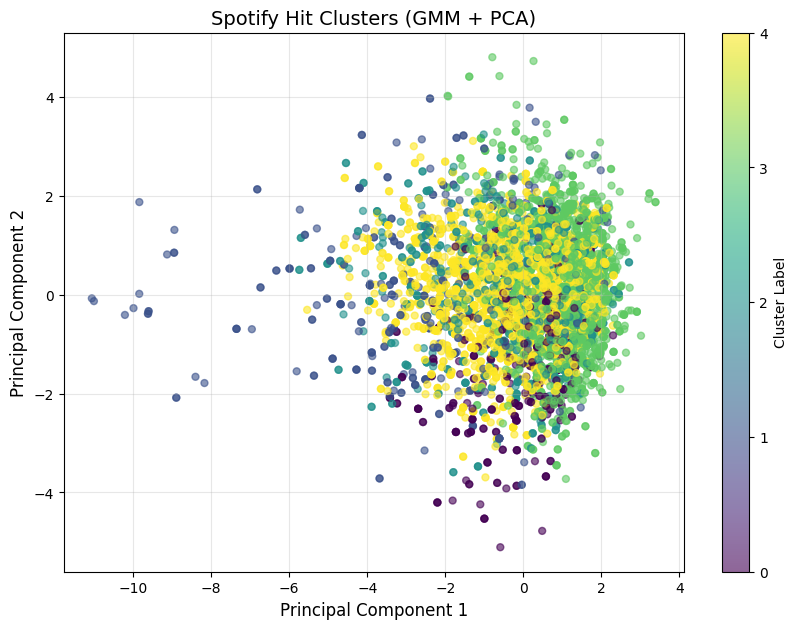

In [126]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_results[:, 0], pca_results[:, 1], 
    c=hit_df['Cluster_GMM'], 
    cmap='viridis', 
    s=25, alpha=0.6
)

plt.title('Spotify Hit Clusters (GMM + PCA)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.colorbar(scatter, ticks=range(5), label='Cluster Label')
plt.grid(True, alpha=0.3)
plt.show()

/var/folders/32/cjb5rw_97rjb1kkd58x5p4q80000gn/T/ipykernel_20776/715316790.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


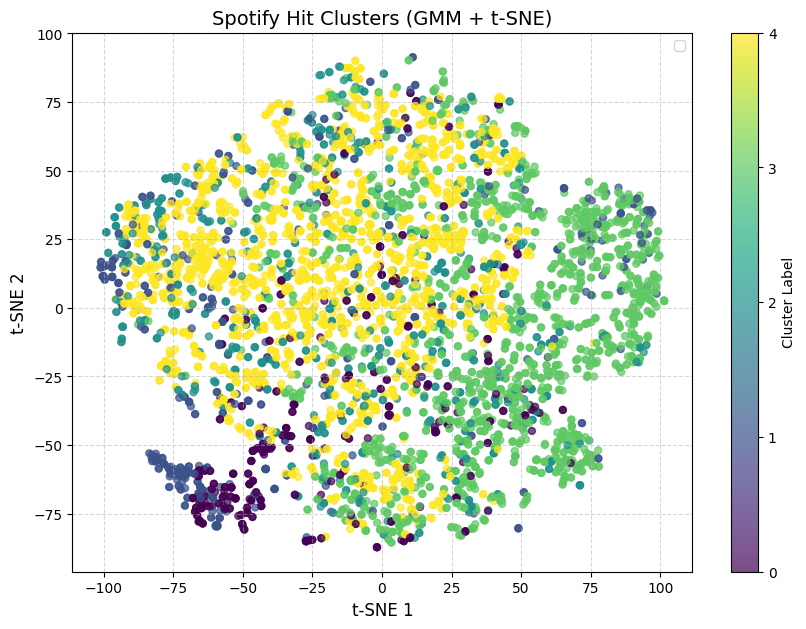

In [127]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(successful_scaled)

# Visualize the clusters
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    tsne_results[:, 0], tsne_results[:, 1], 
    c=hit_df['Cluster_GMM'], 
    cmap='viridis', 
    s=25, alpha=0.7
)

plt.title("Spotify Hit Clusters (GMM + t-SNE)", fontsize=14)
plt.xlabel("t-SNE 1", fontsize=12)
plt.ylabel("t-SNE 2", fontsize=12)
plt.colorbar(scatter, ticks=range(5), label='Cluster Label')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

### Cluster from GMM Interpretation

Using Gaussian Mixture Models (GMM), we identified 5 success archetypes that capture the probabilistic "soft" boundaries of the music market. This method accounts for overlapping styles and provides a nuanced view of song profiles.

---

#### **Cluster 0**
* **Signature Features:** Highest **Duration** (249.5s) and High **Energy** (0.758).
* **Vibe:** These are powerful, longer-form tracks that likely include **Rock, Metal, or Progressive Electronic** hits. They feature significant instrumental sections and high dynamic range.
* **Success Logic:** Success is driven by sonic intensity and immersive arrangements that demand a longer attention span from the listener.

#### **Cluster 1**
* **Signature Features:** Highest **Instrumentalness** (0.278), Highest **Acousticness** (0.481), and Lowest **Loudness** (-10.77 dB).
* **Vibe:** This represents the "Vibe-driven" segment of the hits, including **Ambient, Lo-Fi, and Chill-out** tracks. These are quiet and organic, focusing on texture rather than aggressive vocals.
* **Success Logic:** These are "Utility Hits" that excel in contextual playlists meant for studying, sleeping, or background relaxation.

#### **Cluster 2**
* **Signature Features:** Moderate **Acousticness** (0.274) and Balanced **Energy** (0.647).
* **Vibe:** A hybrid between electronic and organic production. This archetype fits **Alternative Pop and Indie Rock**, where traditional instruments blend with modern studio production.
* **Success Logic:** They offer a "cooler" alternative to mainstream pop, succeeding through a balance of authenticity and modern catchiness.

#### **Cluster 3**
* **Signature Features:** Highest **Popularity** (76.51), Highest **Danceability** (0.659), Highest **Loudness** (-5.27 dB), and Highest **Speechiness** (0.127).
* **Vibe:** The dominant chart formula—**Hip-Hop, Reggaeton, and K-Pop**. These tracks are loud, extremely rhythmic, and vocal-centric.
* **Success Logic:** This is the peak commercial archetype, optimized for club rotation, streaming virality (TikTok/Reels), and radio dominance.

#### **Cluster 4**
* **Signature Features:** Lowest **Speechiness** (0.041) and Smooth **Energy** (0.636).
* **Vibe:** Professional, melodic **Contemporary Pop and Soft Rock**. These tracks prioritize clean vocal melodies and "standard" hit production without the rhythmic aggression of the urban cluster.
* **Success Logic:** These are universally accessible hits designed for broad appeal across diverse age groups and commercial settings.

---